# Project 5 Title

# Unveiling the Android App Market: Analyzing Google Play Store Data

# Objective

- To analyze Google Play Store app data using Python.
- To clean and preprocess the dataset for accurate analysis.
- To explore app categories, ratings, installs, and pricing trends.
- To visualize app market patterns using charts and graphs.
- To generate meaningful insights from Play Store data.

In [2]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Loading the Dataset

df = pd.read_csv("apps.csv")

# Display First 5 Rows

df.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [7]:
# Shape of Dataset

df.shape

(9659, 14)

In [8]:
# Columns Name

df.columns

Index(['Unnamed: 0', 'App', 'Category', 'Rating', 'Reviews', 'Size',
       'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated',
       'Current Ver', 'Android Ver'],
      dtype='object')

In [9]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB


In [10]:
# Statistical Summary

df.describe()

,Unnamed: 0,Rating,Reviews,Size
count,9659.000000,8196.000000,9.659000e+03,8432.000000
mean,5666.172896,4.173243,2.165926e+05,20.395327
std,3102.362863,0.536625,1.831320e+06,21.827509
min,0.000000,1.000000,0.000000e+00,0.000000
25%,3111.500000,4.000000,2.500000e+01,4.600000
50%,5814.000000,4.300000,9.670000e+02,12.000000
75%,8327.500000,4.500000,2.940100e+04,28.000000
max,10840.000000,5.000000,7.815831e+07,100.000000


In [11]:
# Checking Missing Values

df.isnull().sum()

Unnamed: 0           0
App                  0
Category             0
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

In [12]:
# Removing Missing Values

df.dropna(inplace = True)

In [15]:
# Checking Duplicate Rows

df.duplicated().sum()

np.int64(0)

In [17]:
# Removing Duplicate Rows

df.drop_duplicates(inplace = True)

In [18]:
# Cleaning Installs Column

df['Installs'] = df['Installs'].str.replace('+', '')

df['Installs'] = df['Installs'].str.replace(',', '')

df['Installs'] = df['Installs'].astype(int)

In [19]:
# Cleaning Price Column

df['Price'] = df['Price'].str.replace('$', '')

df['Price'] = df['Price'].astype(float)

In [20]:
# Top App Categories

top_categories = df['Category'].value_counts().head(10)

top_categories

Category
FAMILY             1511
GAME                832
TOOLS               625
PERSONALIZATION     274
LIFESTYLE           269
MEDICAL             266
FINANCE             258
PRODUCTIVITY        223
BUSINESS            222
SPORTS              221
Name: count, dtype: int64

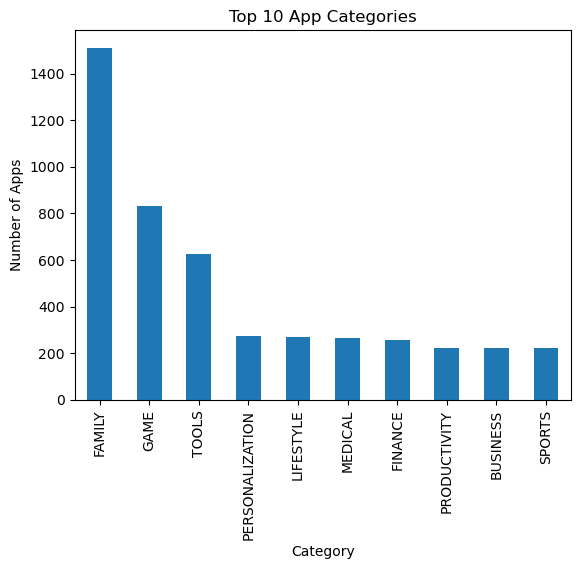

In [21]:
# Visualization of Top Categories

top_categories.plot(kind='bar')

plt.title("Top 10 App Categories")

plt.xlabel("Category")

plt.ylabel("Number of Apps")

plt.show()

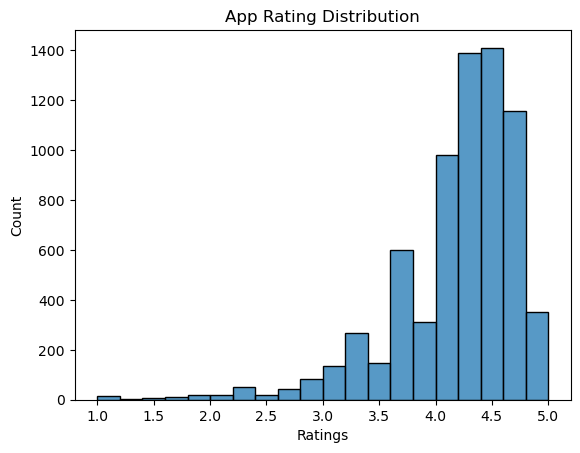

In [22]:
# Rating Distribution

sns.histplot(df['Rating'], bins=20)

plt.title("App Rating Distribution")

plt.xlabel("Ratings")

plt.ylabel("Count")

plt.show()

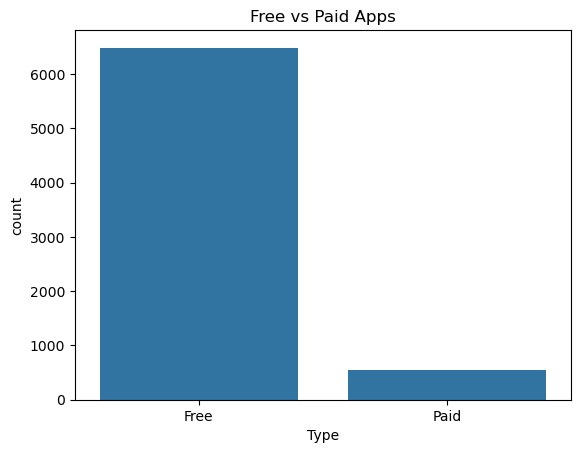

In [23]:
# Free vs Paid Apps

sns.countplot(x='Type', data=df)

plt.title("Free vs Paid Apps")

plt.show()

In [24]:
# Top Installed Apps Categories

install_category = df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)

install_category

Category
GAME                  11532352717
FAMILY                 3552661580
TOOLS                  2879553500
COMMUNICATION          1817915530
PHOTOGRAPHY            1493893130
PRODUCTIVITY           1296302080
NEWS_AND_MAGAZINES     1190900550
PERSONALIZATION         895131930
VIDEO_PLAYERS           866662200
SPORTS                  806311465
Name: Installs, dtype: int64

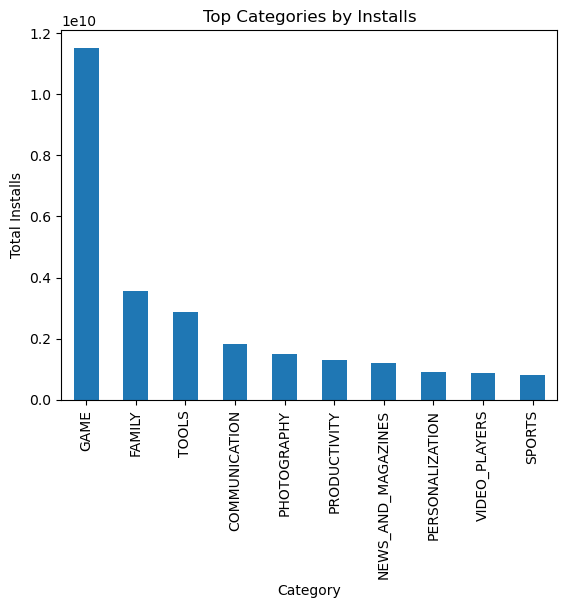

In [25]:
# Visualization of App Installs

install_category.plot(kind='bar')

plt.title("Top Categories by Installs")

plt.xlabel("Category")

plt.ylabel("Total Installs")

plt.show()

In [26]:
# Average Rating by Category

avg_rating = df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)

avg_rating

Category
EVENTS                 4.478947
ART_AND_DESIGN         4.381034
EDUCATION              4.373864
PARENTING              4.347727
PERSONALIZATION        4.324453
BOOKS_AND_REFERENCE    4.322695
BEAUTY                 4.291892
SOCIAL                 4.257692
WEATHER                4.242000
GAME                   4.235697
Name: Rating, dtype: float64

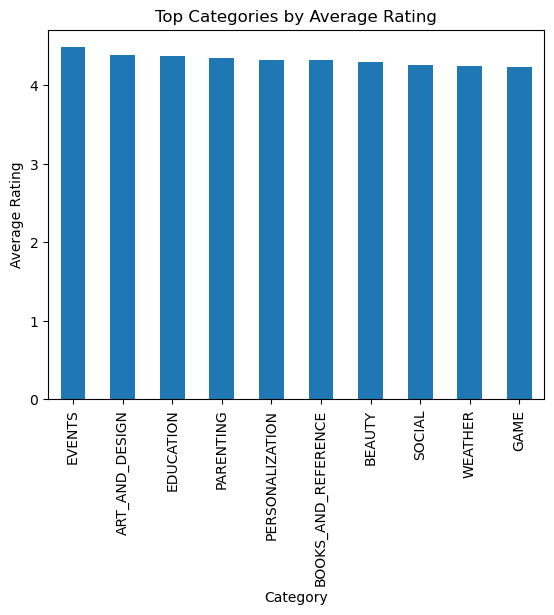

In [27]:
# Visualization of Average Ratings

avg_rating.plot(kind='bar')

plt.title("Top Categories by Average Rating")

plt.xlabel("Category")

plt.ylabel("Average Rating")

plt.show()

In [28]:
# Most Expensive Apps

df[['App', 'Price']].sort_values(by='Price', ascending=False).head(10)

,App,Price
3469,I'm Rich - Trump Edition,400.00
3465,💎 I'm rich,399.99
3327,most expensive app (H),399.99
4413,I am Rich,399.99
4417,I AM RICH PRO PLUS,399.99
4408,I am rich (Most expensive app),399.99
4406,I Am Rich Pro,399.99
4403,I am rich(premium),399.99
4402,I am Rich!,399.99
4400,I Am Rich Premium,399.99


In [29]:
# Saving Cleaned Dataset

df.to_csv("cleaned_googleplaystore_data.csv", index=False)

# Conclusion

- Successfully analyzed Google Play Store data using Python.
- Performed data cleaning and preprocessing techniques.
- Explored app categories, ratings, installs, and pricing trends.
- Generated meaningful insights using visualizations and statistical analysis.
- Improved understanding of Android app market behavior and user preferences.
- This project demonstrates practical skills in:
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualization
- Python Programming
- Google Play Store Data Analysis